# **IT549 Lab Assignment 4: Object Detection Evolution: From R-CNN to YOLO**

Name: Suryadeepsinh Gohil

ID: 202301463

**Environment Setup**

In [ ]:
!pip install ultralytics --quiet
!pip install opencv-python-headless --quiet
!pip install torchvision --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 37.0 MB/s eta 0:00:00


In [ ]:
!unzip -q train.zip -d train_dir/
!unzip -q test.zip -d test_dir/

In [ ]:
import os
import cv2
import time
import glob
import torch
import torchvision
import numpy as np
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# GPU Check
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


**Preparation: Ground Truth Visualization**

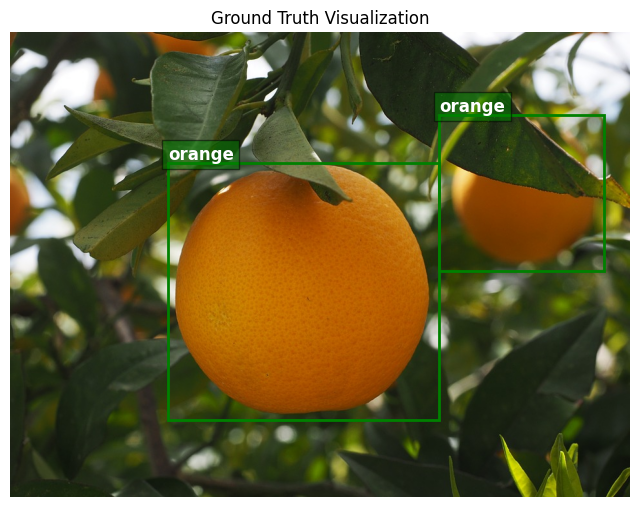

In [11]:
import random

# Helper to parse PASCAL VOC XML annotations
def parse_xml(xml_file):
    tree = ET.parse(xml_file)
    root = tree.getroot()
    boxes, labels = [], []
    for obj in root.findall('object'):
        label = obj.find('name').text
        bndbox = obj.find('bndbox')
        xmin = int(bndbox.find('xmin').text)
        ymin = int(bndbox.find('ymin').text)
        xmax = int(bndbox.find('xmax').text)
        ymax = int(bndbox.find('ymax').text)
        boxes.append([xmin, ymin, xmax, ymax])
        labels.append(label)
    return boxes, labels

# Load a random image from the train directory
img_paths = glob.glob('train_dir/**/*.jpg', recursive=True)
assert len(img_paths) > 0, "No images found in train_dir"
sample_img_path = random.choice(img_paths)
sample_xml_path = sample_img_path.replace('.jpg', '.xml')

img_bgr = cv2.imread(sample_img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
gt_boxes, gt_labels = parse_xml(sample_xml_path)

# Visualize Ground Truth
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(img_rgb)
for box, label in zip(gt_boxes, gt_labels):
    xmin, ymin, xmax, ymax = box
    width, height = xmax - xmin, ymax - ymin
    rect = patches.Rectangle((xmin, ymin), width, height, linewidth=2, edgecolor='g', facecolor='none')
    ax.add_patch(rect)
    ax.text(xmin, ymin - 5, label, color='white', fontsize=12, weight='bold', bbox=dict(facecolor='green', alpha=0.5))
plt.title("Ground Truth Visualization")
plt.axis('off')
plt.show()

**Task 1 - Core Concept: Intersection over Union (IoU)**

In [ ]:
def calculate_iou(box1, box2):
    # Boxes are in [x_min, y_min, x_max, y_max] format
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    # Calculate intersection area
    intersection = max(0, x2 - x1) * max(0, y2 - y1)

    # Calculate union area
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection

    return intersection / union if union > 0 else 0.0

# Demonstration on 3 hardcoded pairs
box_a = [10, 10, 100, 100]
box_highly_overlapping = [15, 15, 95, 95]
box_partially_overlapping = [50, 50, 150, 150]
box_disjoint = [200, 200, 300, 300]

print(f"Highly Overlapping IoU: {calculate_iou(box_a, box_highly_overlapping):.4f}")
print(f"Partially Overlapping IoU: {calculate_iou(box_a, box_partially_overlapping):.4f}")
print(f"Disjoint IoU: {calculate_iou(box_a, box_disjoint):.4f}")

Highly Overlapping IoU: 0.7901
Partially Overlapping IoU: 0.1603
Disjoint IoU: 0.0000


**Task 2 - The Baseline: Selective Search (R-CNN Step 1)**

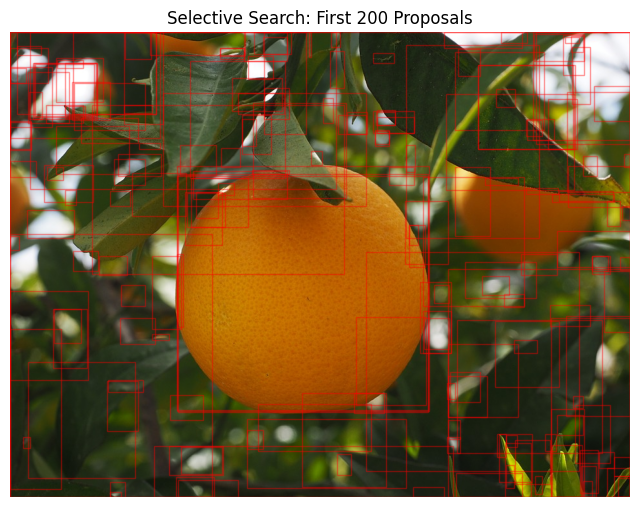

In [12]:
# Setup OpenCV Selective Search
ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
ss.setBaseImage(img_rgb)
ss.switchToSelectiveSearchFast()

# Run SS
rects = ss.process()

# Extract top 200 region proposals and convert [x, y, w, h] -> [x_min, y_min, x_max, y_max]
proposals = []
for (x, y, w, h) in rects[:200]:
    proposals.append([x, y, x + w, y + h])

# Visualize
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(img_rgb)
for box in proposals:
    xmin, ymin, xmax, ymax = box
    rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, linewidth=1, edgecolor='r', facecolor='none', alpha=0.4)
    ax.add_patch(rect)
plt.title("Selective Search: First 200 Proposals")
plt.axis('off')
plt.show()

**Task 3 - Implementing the R-CNN Bottleneck**

In [27]:
# Convert image to tensor [C, H, W]
img_tensor = torchvision.transforms.functional.to_tensor(img_rgb).to(device)

# Load ResNet18 and remove the fully connected layer
resnet18 = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
resnet18_features = torch.nn.Sequential(*list(resnet18.children())[:-1]).eval().to(device)

start_time = time.time()
with torch.no_grad():
    for box in proposals[:100]:
        xmin, ymin, xmax, ymax = box
        # Prevent zero-size crops by adding 1 pixel if necessary
        xmax = max(xmax, xmin + 1)
        ymax = max(ymax, ymin + 1)

        # Crop and resize
        crop = img_tensor[:, ymin:ymax, xmin:xmax].unsqueeze(0)
        crop_resized = torch.nn.functional.interpolate(crop, size=(224, 224), mode='bilinear', align_corners=False)

        # Extract features
        features = resnet18_features(crop_resized)

rcnn_time = time.time() - start_time
print(f"R-CNN Bottleneck Execution Time (100 passes): {rcnn_time:.4f} seconds")

R-CNN Bottleneck Execution Time (100 passes): 0.2978 seconds


**Task 4 - Implementing Fast R-CNN (RoI Pooling)**

In [28]:
# For RoI pooling, we need the spatial feature map.
# ResNet18 downsamples the image by a factor of 32 at layer 4 (which is children[:-2])
resnet_spatial = torch.nn.Sequential(*list(resnet18.children())[:-2]).eval().to(device)

start_time = time.time()
with torch.no_grad():
    # Single CNN pass for the entire image
    feature_map = resnet_spatial(img_tensor.unsqueeze(0))
    spatial_scale = 1.0 / 32.0

    # Format boxes for roi_pool: [batch_index, xmin, ymin, xmax, ymax]
    # Since we only have 1 image in the batch, batch_index is 0 for all boxes.
    roi_boxes_tensor = [torch.tensor([0, b[0], b[1], b[2], b[3]], dtype=torch.float32).to(device) for b in proposals[:100]]
    roi_boxes_tensor = torch.stack(roi_boxes_tensor)

    # Apply RoI Pooling
    pooled_features = torchvision.ops.roi_pool(feature_map, roi_boxes_tensor, output_size=(7, 7), spatial_scale=spatial_scale)

fast_rcnn_time = time.time() - start_time
print(f"Fast R-CNN Execution Time (1 pass + RoI Pool): {fast_rcnn_time:.4f} seconds")
print(f"Speedup Factor: {rcnn_time / fast_rcnn_time:.2f}x")

Fast R-CNN Execution Time (1 pass + RoI Pool): 0.0238 seconds
Speedup Factor: 12.53x


**Conceptual Analysis:** Fast R-CNN solves a major problem in older detection methods by avoiding repeated CNN work for every region proposal. Instead of running separate forward passes on thousands of overlapping crops, it runs the convolutional layers only once on the whole image, which changes the process from O(N) CNN passes to just O(1) CNN pass. Then it uses the shared feature map and pools the features for each proposed box from that map, so the model gets the needed information much faster and without doing the same computations again and again.

**Task 5 - Faster R-CNN**

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 187MB/s]


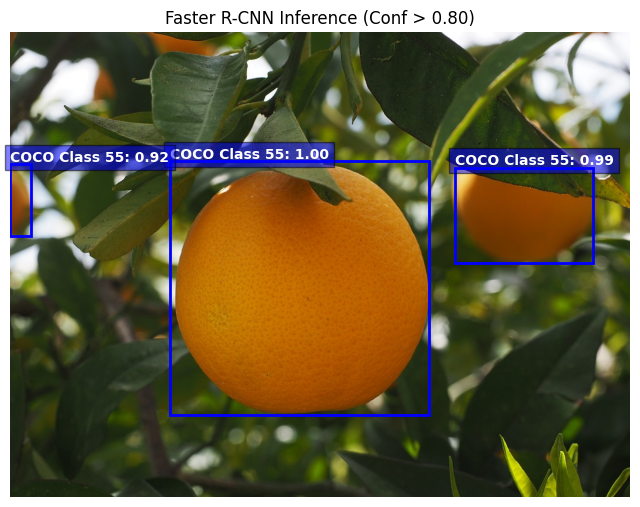

In [29]:
# Load Pre-trained Faster R-CNN
faster_rcnn = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
faster_rcnn.eval().to(device)

start_time_frcnn = time.time()
with torch.no_grad():
    predictions = faster_rcnn(img_tensor.unsqueeze(0))[0]
frcnn_inf_time = time.time() - start_time_frcnn

# Function to filter predictions based on a confidence threshold
def filter_predictions(preds, threshold=0.80):
    boxes = preds['boxes'].cpu().numpy()
    scores = preds['scores'].cpu().numpy()
    labels = preds['labels'].cpu().numpy()

    mask = scores >= threshold
    return boxes[mask], scores[mask], labels[mask]

f_boxes, f_scores, f_labels = filter_predictions(predictions, 0.80)

# COCO labels: 47 is Apple, 46 is Banana, 49 is Orange. Faster R-CNN is trained on COCO.
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(img_rgb)
for box, score, label in zip(f_boxes, f_scores, f_labels):
    xmin, ymin, xmax, ymax = box
    rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, linewidth=2, edgecolor='blue', facecolor='none')
    ax.add_patch(rect)
    ax.text(xmin, ymin - 5, f"COCO Class {label}: {score:.2f}", color='white', fontsize=10, weight='bold', bbox=dict(facecolor='blue', alpha=0.5))
plt.title("Faster R-CNN Inference (Conf > 0.80)")
plt.axis('off')
plt.show()

**Conceptual Analysis:** How does the RPN eliminate the need for external algorithms like Selective Search?

The RPN is the first step in Faster R-CNN, and it is a fully convolutional network. It slides a small window over the feature map made by the backbone and uses fixed anchor boxes with different sizes and shapes to predict which areas may contain objects and how the boxes should be adjusted. Since it uses the same convolutional features as the detector, it avoids slow classical methods like Selective Search that usually run on the CPU.

**Task 6 - Non-Maximum Suppression (NMS)**

In [39]:
def custom_nms(boxes, scores, iou_threshold=0.5):
    # Convert inputs to list for easy indexing
    boxes = list(boxes)
    scores = list(scores)

    # Sort boxes by confidence score in descending order
    sorted_indices = np.argsort(scores)[::-1]
    keep_indices = []

    while len(sorted_indices) > 0:
        # Select the box with the highest score
        current_idx = sorted_indices[0]
        keep_indices.append(current_idx)

        remaining_indices = []
        # Compare current best box to all other remaining boxes
        for idx in sorted_indices[1:]:
            iou = calculate_iou(boxes[current_idx], boxes[idx])
            # Discard box if it overlaps too much (IoU > threshold)
            if iou <= iou_threshold:
                remaining_indices.append(idx)

        sorted_indices = remaining_indices

    return keep_indices

raw_boxes = predictions['boxes'].cpu().numpy()
raw_scores = predictions['scores'].cpu().numpy()

kept_idx = custom_nms(raw_boxes, raw_scores, iou_threshold=0.5)
print(f"Total raw boxes predicted: {len(raw_boxes)}")
print(f"Boxes kept after Custom NMS (threshold=0.5): {len(kept_idx)}")

Total raw boxes predicted: 15
Boxes kept after Custom NMS (threshold=0.5): 13


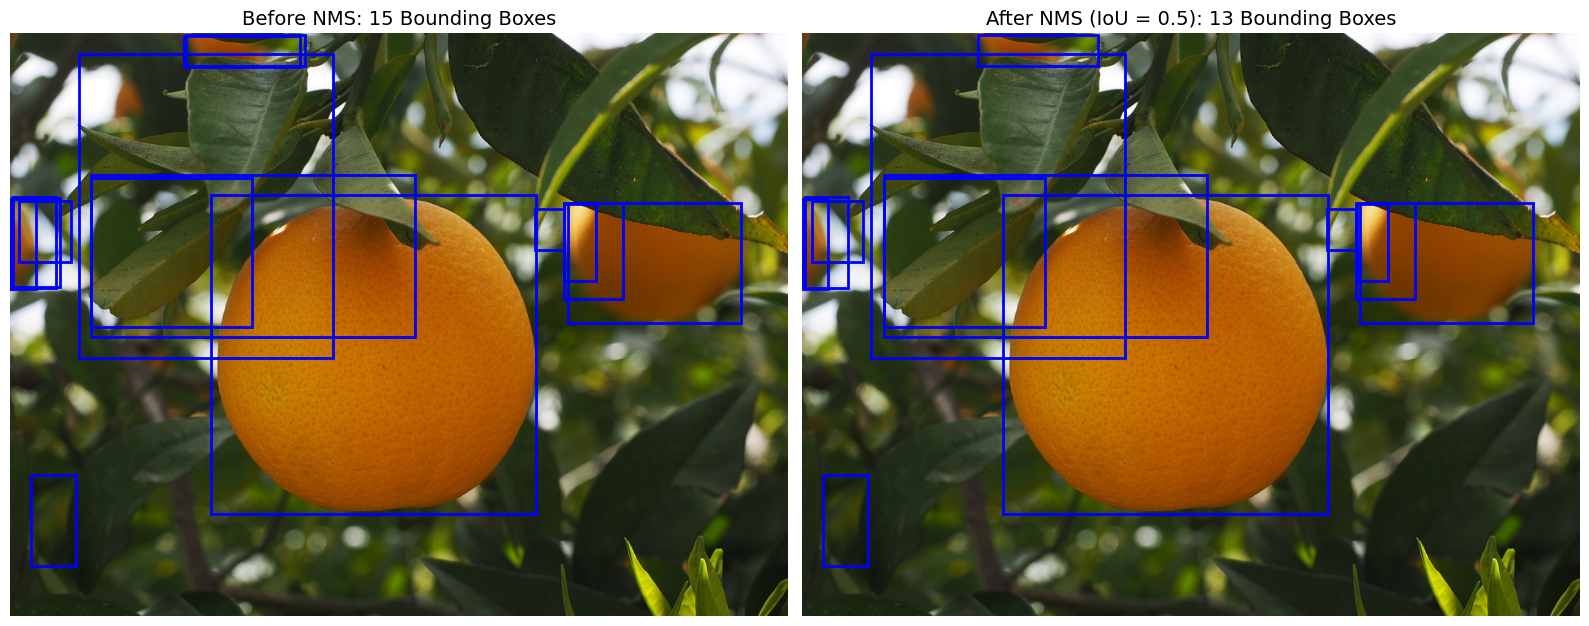

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(img_rgb)
for box in raw_boxes:
    xmin, ymin, xmax, ymax = box
    rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                             linewidth=2, edgecolor='blue', facecolor='none')
    axes[0].add_patch(rect)
axes[0].set_title(f"Before NMS: {len(raw_boxes)} Bounding Boxes", fontsize=14)
axes[0].axis('off')

axes[1].imshow(img_rgb)
for idx in kept_idx:
    xmin, ymin, xmax, ymax = raw_boxes[idx]
    rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                             linewidth=2, edgecolor='blue', facecolor='none')
    axes[1].add_patch(rect)
axes[1].set_title(f"After NMS (IoU = 0.5): {len(kept_idx)} Bounding Boxes", fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

Conceptual Analysis:

What happens if you set the threshold to 0.9 vs 0.1 for a cluster of tightly packed objects?

* **IoU = 0.9 (Extremely High/Lenient):** The final visual prediction will show many duplicate bounding boxes overlapping on the same object. Since a 0.9 threshold means boxes are only discarded if they overlap by 90% or more, boxes covering the same apple but shifted slightly will both be kept.
* **IoU = 0.1 (Extremely Low/Strict):** The algorithm becomes overly aggressive. If you have a basket of apples, detecting one apple will suppress the bounding boxes of neighboring, physically overlapping apples because they share more than 10% area. You will end up predicting fewer objects than are actually present in the cluster.

**Task 7 - YOLO Fine-Tuning**

In [42]:
import os

yolo_dir = 'yolo_data'
os.makedirs(f'{yolo_dir}/images/train', exist_ok=True)
os.makedirs(f'{yolo_dir}/images/val', exist_ok=True)
os.makedirs(f'{yolo_dir}/labels/train', exist_ok=True)
os.makedirs(f'{yolo_dir}/labels/val', exist_ok=True)

class_map = {'apple': 0, 'banana': 1, 'orange': 2}

def convert_xml_to_yolo(xml_file, img_width, img_height):
    boxes, labels = parse_xml(xml_file)
    yolo_labels = []
    for box, label in zip(boxes, labels):
        # Convert to YOLO normalized format: x_center, y_center, width, height
        x_min, y_min, x_max, y_max = box
        x_center = ((x_min + x_max) / 2) / img_width
        y_center = ((y_min + y_max) / 2) / img_height
        w = (x_max - x_min) / img_width
        h = (y_max - y_min) / img_height

        class_id = class_map.get(label.lower(), 0)
        yolo_labels.append(f"{class_id} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}")
    return yolo_labels

import shutil

def process_split(src_dir, split_name):
    img_files = glob.glob(f'{src_dir}/**/*.jpg', recursive=True)
    for img_path in img_files:
        xml_path = img_path.replace('.jpg', '.xml')
        if not os.path.exists(xml_path): continue

        img = cv2.imread(img_path)
        h, w, _ = img.shape

        yolo_labels = convert_xml_to_yolo(xml_path, w, h)

        # Copy image
        base_name = os.path.basename(img_path)
        shutil.copy(img_path, f'{yolo_dir}/images/{split_name}/{base_name}')

        # Write label
        label_path = f'{yolo_dir}/labels/{split_name}/{base_name.replace(".jpg", ".txt")}'
        with open(label_path, 'w') as f:
            f.write("\n".join(yolo_labels))

process_split('train_dir', 'train')
process_split('test_dir', 'val')

# Generate YAML config
yaml_content = f"""
path: {os.path.abspath(yolo_dir)}
train: images/train
val: images/val
nc: 3
names: ['apple', 'banana', 'orange']
"""
with open('fruits.yaml', 'w') as f:
    f.write(yaml_content)

print("YOLO dataset created successfully.")

YOLO dataset created successfully.


Training YOLO for 10 epochs
Training Complete!


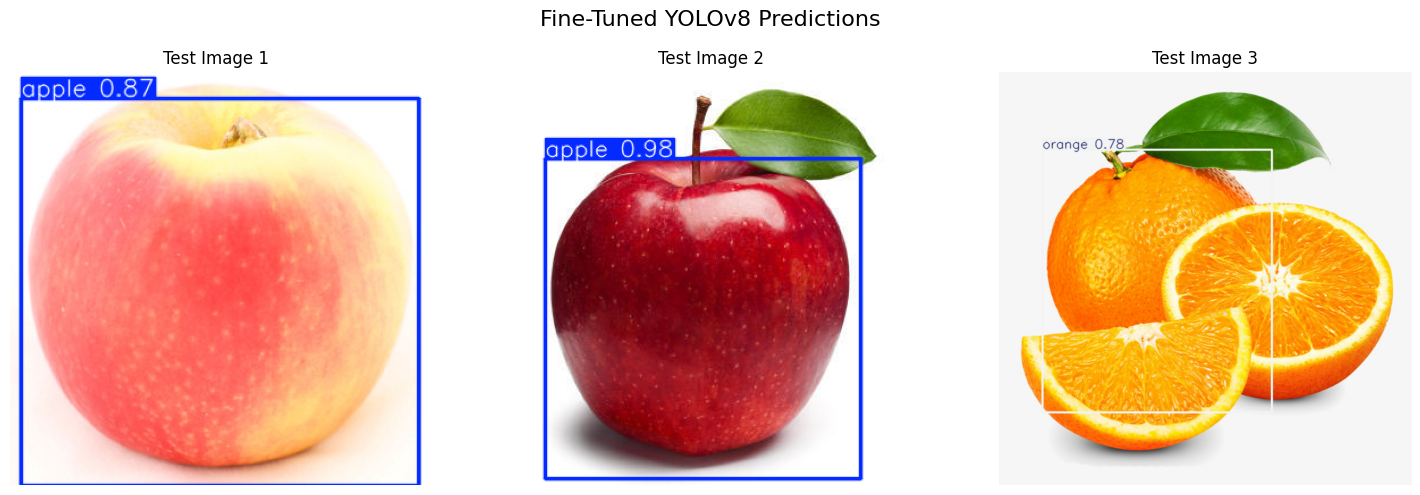


--- Model Evaluation Metrics ---
Fine-Tuned mAP@50:    0.8476
Fine-Tuned mAP@50-95: 0.5940

Evaluating Pre-trained models on Custom Test Set

--- Final Comparison Table ---


,Model,Inference Time (ms/img),Precision,Recall
0,Faster R-CNN (Pre-trained),780.74,0.4558,0.8376
1,YOLOv8 (Pre-trained),69.11,0.6759,0.6239
2,YOLOv8 (Fine-tuned),27.71,0.8312,0.7508


In [47]:
import time
import cv2
import glob
import os
import sys
import contextlib
import torch
import torchvision
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO

@contextlib.contextmanager
def suppress_output():
    with open(os.devnull, "w") as devnull:
        old_stdout = sys.stdout
        old_stderr = sys.stderr
        sys.stdout = devnull
        sys.stderr = devnull
        try:
            yield
        finally:
            sys.stdout = old_stdout
            sys.stderr = old_stderr

with suppress_output():
    yolo_model = YOLO('yolov8n.pt')

# Track Pre-trained Inference time
start_time_yolo = time.time()
with suppress_output():
    _ = yolo_model(sample_img_path)
yolo_pretrained_inf_time = (time.time() - start_time_yolo) * 1000

print("Training YOLO for 10 epochs")
with suppress_output():
    results = yolo_model.train(data='fruits.yaml', epochs=10, imgsz=640, plots=True)
print("Training Complete!")

with suppress_output():
    fine_tuned_yolo = YOLO('runs/detect/train/weights/best.pt')

# Run inference on 3 test images & Track Time
test_imgs = glob.glob(f'{yolo_dir}/images/val/*.jpg')
yolo_ft_inf_times = []

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, img_path in enumerate(test_imgs[:3]):
    start = time.time()
    with suppress_output():
        res = fine_tuned_yolo(img_path)
    yolo_ft_inf_times.append((time.time() - start) * 1000)

    res_plotted = res[0].plot()
    axes[i].imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
    axes[i].axis('off')
    axes[i].set_title(f"Test Image {i+1}")

plt.suptitle("Fine-Tuned YOLOv8 Predictions", fontsize=16)
plt.tight_layout()
plt.show()

# Get Fine-Tuned Metrics
with suppress_output():
    val_metrics = fine_tuned_yolo.val()

print("\n--- Model Evaluation Metrics ---")
print(f"Fine-Tuned mAP@50:    {val_metrics.box.map50:.4f}")
print(f"Fine-Tuned mAP@50-95: {val_metrics.box.map:.4f}")

print("\nEvaluating Pre-trained models on Custom Test Set")

yolo_coco_to_custom = {47: 0, 46: 1, 49: 2}      # Ultralytics mapping
frcnn_coco_to_custom = {53: 0, 52: 1, 55: 2}     # Torchvision mapping

def get_ground_truth(img_path):
    label_path = img_path.replace('images', 'labels').replace('.jpg', '.txt')
    gt_boxes, gt_labels = [], []
    if not os.path.exists(label_path): return gt_boxes, gt_labels
    img_h, img_w = cv2.imread(img_path).shape[:2]
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            c_id = int(parts[0])
            xc, yc, w, h = map(float, parts[1:])
            xmin, ymin = (xc - w/2) * img_w, (yc - h/2) * img_h
            xmax, ymax = (xc + w/2) * img_w, (yc + h/2) * img_h
            gt_boxes.append([xmin, ymin, xmax, ymax])
            gt_labels.append(c_id)
    return gt_boxes, gt_labels

def eval_preds(pred_boxes, pred_labels, pred_scores, gt_boxes, gt_labels):
    tp, fp = 0, 0
    matched_gt = set()
    if len(pred_scores) > 0:
        sorted_indices = np.argsort(pred_scores)[::-1]
        pred_boxes = [pred_boxes[i] for i in sorted_indices]
        pred_labels = [pred_labels[i] for i in sorted_indices]
    for p_box, p_label in zip(pred_boxes, pred_labels):
        best_iou, best_gt_idx = 0, -1
        for j, (g_box, g_label) in enumerate(zip(gt_boxes, gt_labels)):
            if j in matched_gt or g_label != p_label: continue
            iou = calculate_iou(p_box, g_box)
            if iou > best_iou:
                best_iou, best_gt_idx = iou, j
        if best_iou >= 0.5:
            tp += 1
            matched_gt.add(best_gt_idx)
        else:
            fp += 1
    fn = len(gt_boxes) - len(matched_gt)
    return tp, fp, fn

frcnn_tp, frcnn_fp, frcnn_fn = 0, 0, 0
yolo_pt_tp, yolo_pt_fp, yolo_pt_fn = 0, 0, 0

for img_path in test_imgs:
    gt_boxes, gt_labels = get_ground_truth(img_path)
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_tensor = torchvision.transforms.functional.to_tensor(img_rgb).to(device)

    # Faster R-CNN Eval
    with torch.no_grad():
        frcnn_preds = faster_rcnn(img_tensor.unsqueeze(0))[0]
    f_boxes, f_labels, f_scores = [], [], []
    for box, label, score in zip(frcnn_preds['boxes'], frcnn_preds['labels'], frcnn_preds['scores']):
        if score > 0.5 and label.item() in frcnn_coco_to_custom:
            f_boxes.append(box.cpu().numpy())
            f_labels.append(frcnn_coco_to_custom[label.item()])
            f_scores.append(score.cpu().numpy())
    tp, fp, fn = eval_preds(f_boxes, f_labels, f_scores, gt_boxes, gt_labels)
    frcnn_tp += tp; frcnn_fp += fp; frcnn_fn += fn

    # YOLO Pre-trained Eval
    with suppress_output():
        yolo_res = yolo_model(img_path)[0]
    y_boxes, y_labels, y_scores = [], [], []
    for box, label, score in zip(yolo_res.boxes.xyxy, yolo_res.boxes.cls, yolo_res.boxes.conf):
        if score > 0.5 and int(label.item()) in yolo_coco_to_custom:
            y_boxes.append(box.cpu().numpy())
            y_labels.append(yolo_coco_to_custom[int(label.item())])
            y_scores.append(score.cpu().numpy())
    tp, fp, fn = eval_preds(y_boxes, y_labels, y_scores, gt_boxes, gt_labels)
    yolo_pt_tp += tp; yolo_pt_fp += fp; yolo_pt_fn += fn

# Calculate Math
frcnn_prec = frcnn_tp / (frcnn_tp + frcnn_fp) if (frcnn_tp + frcnn_fp) > 0 else 0
frcnn_rec = frcnn_tp / (frcnn_tp + frcnn_fn) if (frcnn_tp + frcnn_fn) > 0 else 0
yolo_pt_prec = yolo_pt_tp / (yolo_pt_tp + yolo_pt_fp) if (yolo_pt_tp + yolo_pt_fp) > 0 else 0
yolo_pt_rec = yolo_pt_tp / (yolo_pt_tp + yolo_pt_fn) if (yolo_pt_tp + yolo_pt_fn) > 0 else 0


avg_ft_inf_time = sum(yolo_ft_inf_times) / len(yolo_ft_inf_times)

table_data = {
    "Model": ["Faster R-CNN (Pre-trained)", "YOLOv8 (Pre-trained)", "YOLOv8 (Fine-tuned)"],
    "Inference Time (ms/img)": [
        f"{frcnn_inf_time * 1000:.2f}",
        f"{yolo_pretrained_inf_time:.2f}",
        f"{avg_ft_inf_time:.2f}"
    ],
    "Precision": [
        f"{frcnn_prec:.4f}",
        f"{yolo_pt_prec:.4f}",
        f"{val_metrics.box.mp:.4f}"
    ],
    "Recall": [
        f"{frcnn_rec:.4f}",
        f"{yolo_pt_rec:.4f}",
        f"{val_metrics.box.mr:.4f}"
    ]
}

df_comparison = pd.DataFrame(table_data)
print("\n--- Final Comparison Table ---")
display(df_comparison)